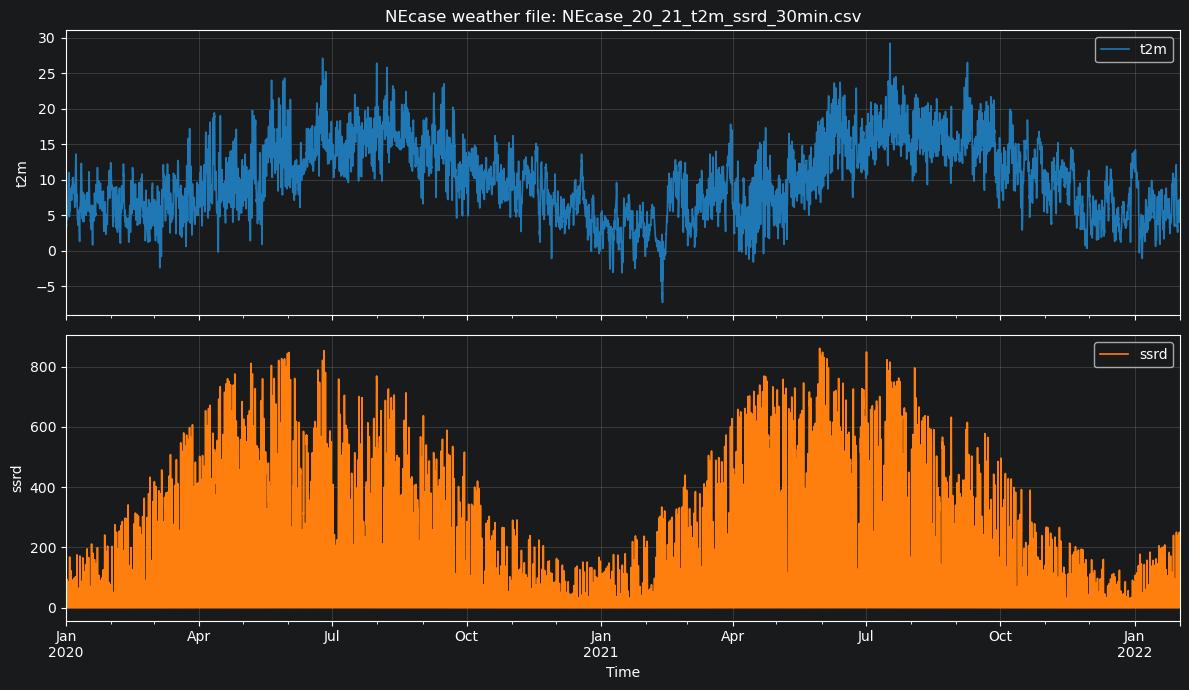

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

weather_path = Path(r"E:\Github\LV-network\Input data\NEcase_20_21_t2m_ssrd_30min.csv")
weather = pd.read_csv(weather_path, parse_dates=["timestamp"]).sort_values("timestamp")
weather = weather.set_index("timestamp")
weather = weather
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

weather["t2m"].plot(ax=axes[0], color="tab:blue", linewidth=1.2, label="t2m")
weather["ssrd"].plot(ax=axes[1], color="tab:orange", linewidth=1.2, label="ssrd")

axes[0].set_title("NEcase weather file: NEcase_20_21_t2m_ssrd_30min.csv")
axes[0].set_ylabel("t2m")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_ylabel("ssrd")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


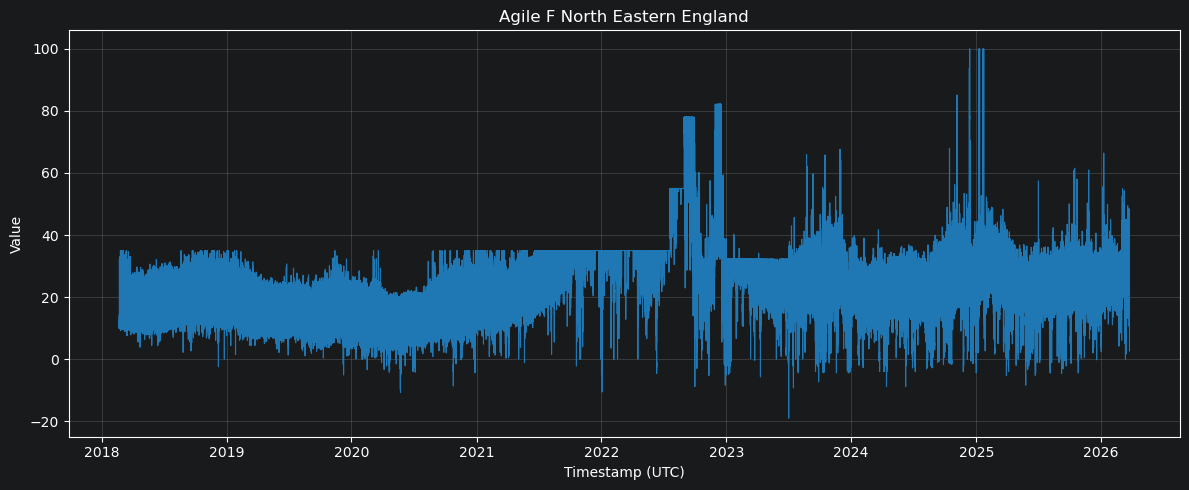

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Input data").exists()), Path.cwd())
agile_path = project_root / "Input data" / "csv_agile_F_North_Eastern_England.csv"

agile = pd.read_csv(
    agile_path,
    header=None,
    names=["timestamp_utc", "settlement_time", "product", "region", "value"],
)
agile["timestamp_utc"] = pd.to_datetime(agile["timestamp_utc"], utc=True, errors="coerce")
agile["value"] = pd.to_numeric(agile["value"], errors="coerce")
agile = agile.dropna(subset=["timestamp_utc", "value"]).sort_values("timestamp_utc")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agile["timestamp_utc"], agile["value"], linewidth=0.8, color="tab:blue")
ax.set_title("Agile F North Eastern England")
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
